# Exercise 08: Seaborn

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
# NEED TO INSTALL Seaborn

conn = sqlite3.connect('../data/checking-logs.sqlite')

## Main query

In [2]:
# correct query (IMPORTANT: numTrials)
df = pd.read_sql("""
SELECT uid, timestamp, numTrials
FROM checker
WHERE uid LIKE 'user_%'
AND labname = 'project1'
AND status = 'ready'
""", conn)

conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['uid', 'timestamp'])


## Plotting the Line graph

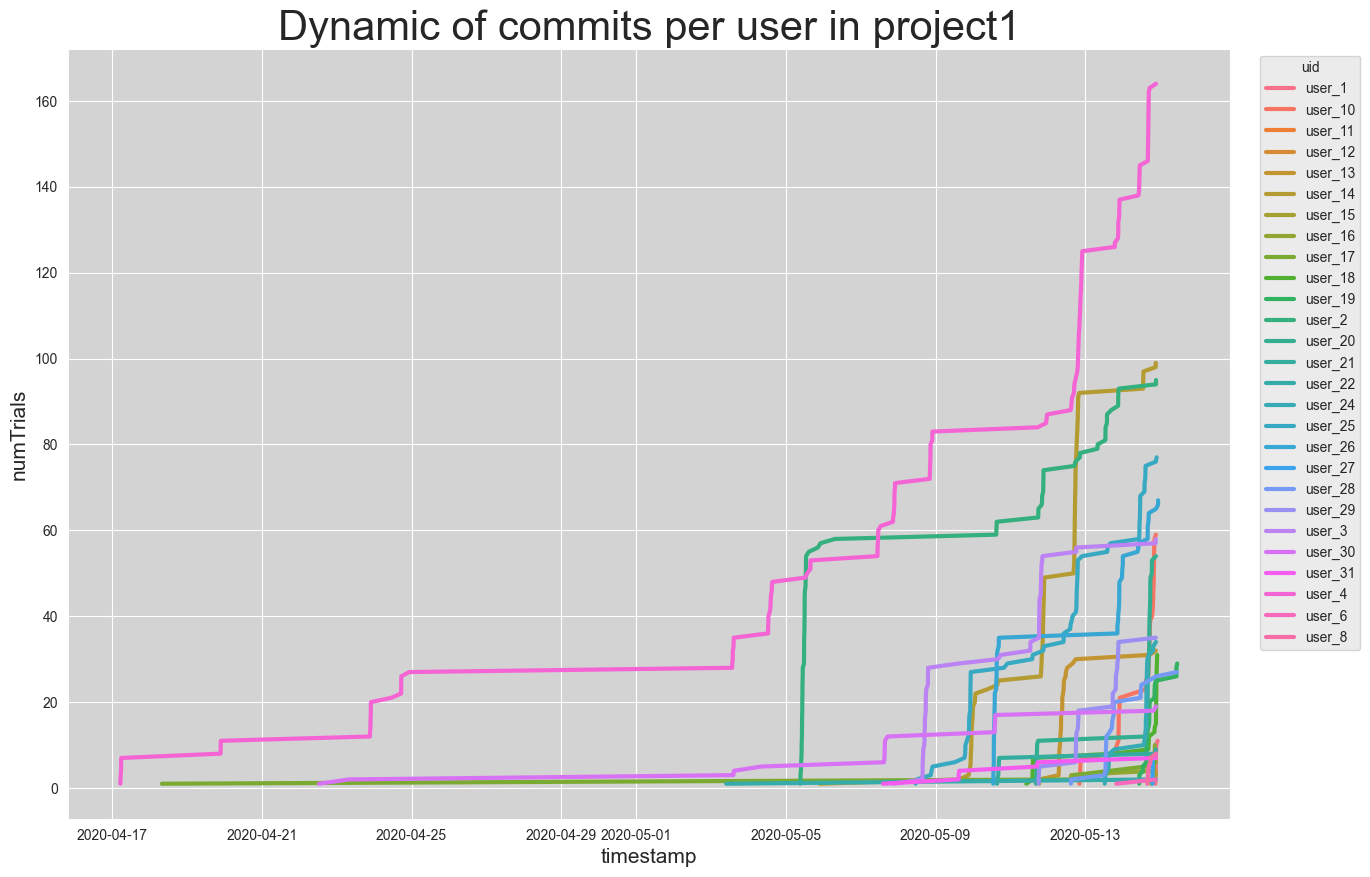

In [3]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
plt.figure(figsize=(15, 10))

ax = sns.lineplot(
    data=df,
    x='timestamp',
    y='numTrials',
    hue='uid',
    linewidth=3
)

ax.set_facecolor('lightgray')

plt.title('Dynamic of commits per user in project1', fontsize=30)
plt.xlabel('timestamp', fontsize=15)
plt.ylabel('numTrials', fontsize=15)

plt.legend(title='uid', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

## Answering questions 

Which user was the leader in the number of commits almost all of the time? The answer is user_4

Which user was the leader for only a short period of time?" The answer is user_25